## 1. Setup

### 1.1 Importar Libs

In [2]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import json
import pickle
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, loguniform, randint
from joblib import dump, load
import warnings


warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import evaluate_model, load_and_prepare_datasets, SCORING_METRIC
from search_utils import (plot_search_history, multiple_randomized_search,
                          plot_search_history_from_loaded, 
                          load_search_results, get_best_params_from_saved,
                          save_search_results, save_final_results, 
                          DEFAULT_CV_STRATEGY, MODELS_FOLDER, RESULTS_FOLDER, SEARCHES_FOLDER)
try:
    import xgboost as xgb
except:
    print("❌ XGBoost não encontrado. Instale com: pip install xgboost")

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")

Bibliotecas importadas com sucesso!
Pandas: 2.3.3
NumPy: 2.3.5
Scikit-learn: 1.7.2
XGBoost: 3.1.2


### 1.2 Configuração do Modelo

In [3]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "XGBoost"
MODEL_CLASS = xgb.XGBClassifier
RANDOM_STATE_MODEL = 42
RANDOM_STATE_SAMPLE = 10

# Configuração da busca de hiperparâmetros
N_SEARCHES = 20
N_ITER_PER_SEARCH = 5
SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search

print(f"Modelo configurado: {MODEL_NAME}")
print(f"Buscas: {N_SEARCHES} x {N_ITER_PER_SEARCH} iterações")

Modelo configurado: XGBoost
Buscas: 20 x 5 iterações


## 2. Carregamento e Preparação dos Dados

In [4]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, train_data, test_data, scaler = load_and_prepare_datasets()

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", y_train.value_counts().to_dict())
print("Teste:", y_test.value_counts().to_dict())

print("\nPrimeiras linhas do dataset de treino:")

=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (37233, 1825)
Dataset de teste: (12411, 1825)
Features: 1824

Distribuição das classes:
Treino: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}
Teste: {1: 2430, 2: 1790, 3: 1408, 4: 1257, 5: 1203, 6: 995, 7: 912, 8: 815, 0: 813, 9: 788}

Primeiras linhas do dataset de treino:


In [4]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,1815,1816,1817,1818,1819,1820,1821,1822,1823,digit
0,0.132290,-0.078874,-0.007970,0.126206,-0.019496,0.049232,0.118899,-0.035883,0.027992,0.031445,...,1.514577,1.355709,1.418220,1.314246,1.393841,1.382280,1.272189,1.350409,1.342505,1
1,-1.261489,-1.223371,-1.000089,-1.225078,-1.232434,-0.959512,-1.124728,-1.226982,-0.848620,-1.207445,...,-1.251411,-1.451988,-1.167611,-1.313675,-1.466612,-1.229501,-1.268458,-1.301135,-1.067532,1
2,-0.803139,-0.742865,-0.624391,-0.887569,-0.834537,-0.721469,-0.968023,-0.922214,-0.717852,-0.951887,...,-1.567787,-1.773163,-1.590253,-1.399433,-1.590376,-1.392650,-1.309864,-1.443503,-1.416043,1
3,0.495477,0.708491,0.804662,0.502907,0.720904,0.816273,0.587815,0.800239,0.893713,0.593013,...,0.951751,0.926661,1.139622,0.921222,0.899732,1.112191,0.930080,0.907232,1.048508,2
4,0.731854,0.843948,0.588933,0.628960,0.746698,0.552313,0.452046,0.575681,0.506712,0.329009,...,0.918366,0.802927,0.817431,0.947489,0.807747,0.683944,0.860839,0.730585,0.559723,2


## 3. Sampling para Busca de Hiperparâmetros

In [5]:
# ======================================================================
# SAMPLING ESTRATIFICADO PARA BUSCA DE HIPERPARÂMETROS
# ======================================================================

print("=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===")

# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train, 
    test_size=SAMPLE_SIZE,  
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", y_train.value_counts().to_dict())

=== PREPARAÇÃO DE AMOSTRA PARA BUSCA DE HIPERPARÂMETROS ===
Dataset original de treino: 37,233 amostras
Amostra para busca de hiperparâmetros: 1,862 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {1: 352, 2: 279, 3: 214, 4: 187, 5: 171, 7: 145, 6: 143, 0: 127, 8: 127, 9: 117}
Original: {1: 7050, 2: 5577, 3: 4282, 4: 3733, 5: 3430, 7: 2895, 6: 2857, 8: 2537, 0: 2533, 9: 2339}


## 4. Definir Estratégia de Validação Cruzada

In [ ]:
# Usar estratégia de CV padrão dos módulos
print(f"Estratégia de CV: {DEFAULT_CV_STRATEGY}")

## 5. XGBoost - Busca de Hiperparâmetros


### 5.1 Definir Espaço de Hiperparâmetros


In [ ]:
# ======================================================================
# DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS
# ======================================================================

# Definir hiperparâmetros específicos para XGBoost
param_distributions = {
    'n_estimators': randint(100, 250),  # Número de árvores
    'max_depth': randint(5, 40),  # Profundidade máxima das árvores
    'learning_rate': uniform(0.7, 1.5),  # Taxa de aprendizado
    'subsample': uniform(0.4, 0.5),  # Fração das amostras para cada árvore
    'colsample_bytree': uniform(0.3, 0.4),  # Fração das features para cada árvore
    'reg_alpha': uniform(1.5, 1.5),  # Regularização L1
    'reg_lambda': uniform(2, 2.5),  # Regularização L2
    'min_child_weight': randint(4, 20),  # Peso mínimo das folhas 
    'gamma': uniform(0.15, 0.75),  # Redução mínima de perda para split 
}

### 5.2 Executar Busca de Hiperparâmetros

In [8]:
# ======================================================================
# BUSCA DE HIPERPARAMETROS
# ======================================================================

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Executando {N_SEARCHES} buscas com {N_ITER_PER_SEARCH} iterações cada...")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")

# Múltiplas execuções do RandomizedSearchCV
search, all_searches, best_params = multiple_randomized_search(
    estimator=MODEL_CLASS(
        objective='multi:softprob', 
        num_class=10,              
        eval_metric='mlogloss',     
        random_state=RANDOM_STATE_MODEL,
        n_jobs=-1,
        verbosity=0
    ),
    param_distributions=param_distributions,
    X=X_sample,
    y=y_sample,
    cv_strategy=DEFAULT_CV_STRATEGY,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    n_jobs=-1
)

# Exibir os melhores resultados
print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {search.best_score_:.4f}")
print(f"Desvio padrão: {search.cv_results_['std_test_score'][search.best_index_]:.4f}")

=== BUSCA DE HIPERPARÂMETROS - XGBoost ===
Iniciando busca de hiperparâmetros para XGBoost...
Executando 20 buscas com 5 iterações cada...
Usando amostra de 1,862 exemplos

Executando 20 buscas com 5 iterações cada...

Busca 1/20...
Melhor score desta busca: 0.4396
Melhor configuração desta busca: {'colsample_bytree': np.float64(0.5353764929244422), 'gamma': np.float64(0.7725637385575413), 'learning_rate': np.float64(0.7388769242636961), 'max_depth': 39, 'min_child_weight': 11, 'n_estimators': 233, 'reg_alpha': np.float64(2.621766640170792), 'reg_lambda': np.float64(2.3485393910162835), 'subsample': np.float64(0.8103815035454902)}
Melhor score geral até agora: 0.4396

Busca 2/20...
Melhor score desta busca: 0.3852
Melhor configuração desta busca: {'colsample_bytree': np.float64(0.4693769854511275), 'gamma': np.float64(0.21588096375368013), 'learning_rate': np.float64(1.4755010716790669), 'max_depth': 30, 'min_child_weight': 18, 'n_estimators': 122, 'reg_alpha': np.float64(1.91178319402

### 5.3 Visualizar Histórico da Busca


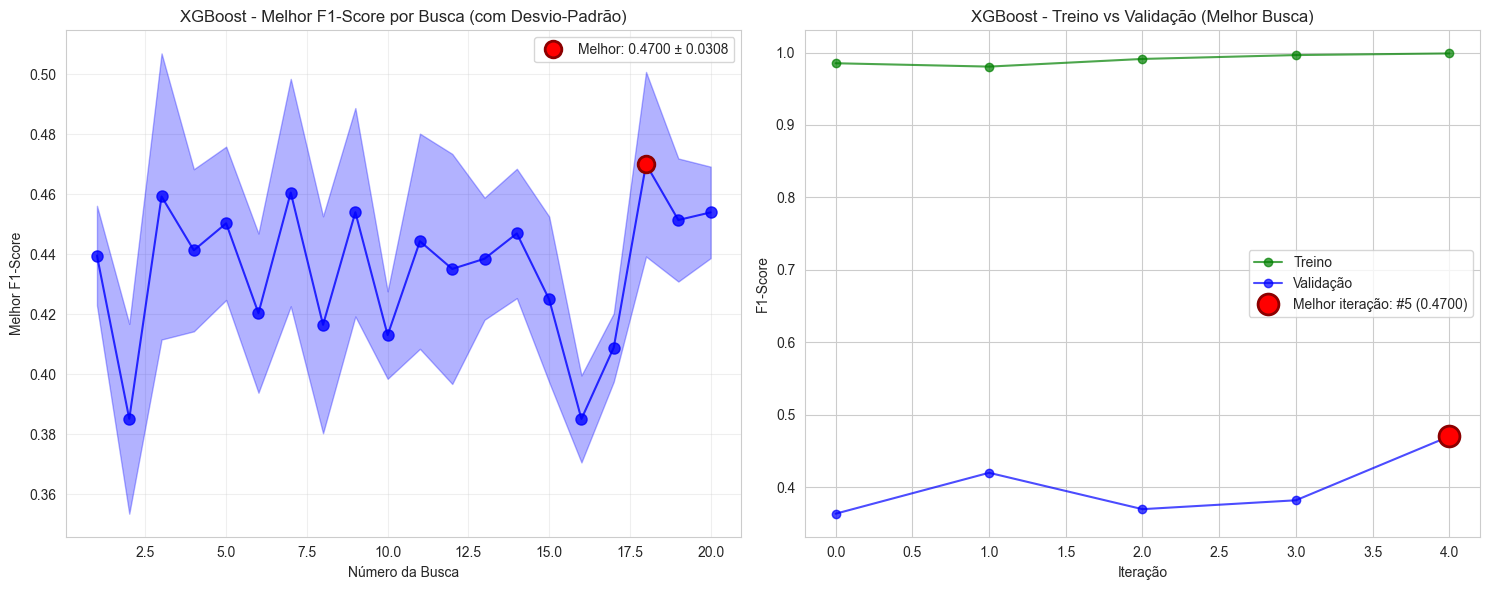

In [9]:
# Registro de Desempenho - plotar evolução da busca
plot_search_history(all_searches, search, MODEL_NAME)

In [10]:
# ======================================================================
# ANÁLISE DAS MELHORES CONFIGURAÇÕES ENCONTRADAS
# ======================================================================

print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS POR BUSCA - {MODEL_NAME} ===")

# Extrair os melhores resultados de cada busca
best_configs = []

for i, search_result in enumerate(all_searches):
    config = {
        'Busca': i + 1,
        'F1_Score': search_result['best_score'],
        **search_result['best_params']
    }
    best_configs.append(config)

# Criar DataFrame e exibir top configs
results_df = pd.DataFrame(best_configs)
results_df = results_df.sort_values('F1_Score', ascending=False).round(4)

print(f"\nTop configurações (de {len(results_df)} buscas):")
print(results_df.to_string(index=False))

print(f"\nEstatísticas dos F1-Scores encontrados:")
print(f"  Média: {results_df['F1_Score'].mean():.4f}")
print(f"  Mediana: {results_df['F1_Score'].median():.4f}")
print(f"  Desvio padrão: {results_df['F1_Score'].std():.4f}")
print(f"  Min: {results_df['F1_Score'].min():.4f}")
print(f"  Max: {results_df['F1_Score'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS POR BUSCA - XGBoost ===

Top configurações (de 20 buscas):
 Busca  F1_Score  colsample_bytree  gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_alpha  reg_lambda  subsample
    18    0.4700            0.6297 0.2972         0.7569         26                19           160     1.9659      4.1051     0.8328
     7    0.4606            0.4394 0.4004         0.8046         28                17           200     1.6767      4.1694     0.8982
     3    0.4593            0.3590 0.5166         0.7944         17                 8           156     1.8070      3.7555     0.6453
     9    0.4540            0.4265 0.2331         0.7934         32                16           198     1.9356      2.1817     0.8198
    20    0.4540            0.4813 0.3118         0.9599         18                 6           109     1.6890      3.9637     0.8530
    19    0.4514            0.4576 0.5961         0.8430         38                15           15

## 6. Salvar Resultados de Busca

In [11]:

search_df = save_search_results(
    model_name=MODEL_NAME,
    model_search=search,
    model_all_searches=all_searches,
    n_searches=N_SEARCHES,
    n_iter_per_search=N_ITER_PER_SEARCH,
    scoring=SCORING_METRIC,
    cv_folds=DEFAULT_CV_STRATEGY.get_n_splits(),
    top_params_columns=param_distributions.keys(),
    searches_folder=SEARCHES_FOLDER
)

=== SALVANDO RESULTADOS DA BUSCA - XGBOOST ===
  ✅ Todos os Resultados salvos: searches\xgboost_all_searches.csv
  Total de configurações testadas: 100
  ✅ Resumo salvo: searches\xgboost_search_summary.json

--- ESTATÍSTICAS DA BUSCA XGBOOST ---
Melhor F1-Score: 0.4700
Desvio padrão do melhor: 0.0308
F1-Score médio geral: 0.3865
F1-Score mínimo: 0.2694
F1-Score máximo: 0.4700


### 6.2 Carregar Resultado de Busca (Opcional)

In [ ]:
loaded_results = load_search_results(MODEL_NAME)

In [ ]:
# Plotar a história da busca a partir dos resultados carregados
plot_search_history_from_loaded(loaded_results, MODEL_NAME)

### 6.3 Definir Melhores Params e CV score

In [12]:
# Definir Melhores Parâmetros para Uso Posterior
if 'loaded_results' in locals():
    best_params = get_best_params_from_saved(MODEL_NAME)
    best_score = loaded_results['summary']['best_overall_score']
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor F1-Score carregado: {best_score:.4f}")
else:
    best_params = search.best_params_
    best_score = search.best_score_
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor F1-Score da busca atual: {best_score:.4f}")

✅ Usando parâmetros da busca atual: {'colsample_bytree': np.float64(0.6297053512265065), 'gamma': np.float64(0.29719953753729855), 'learning_rate': np.float64(0.756914726405786), 'max_depth': 26, 'min_child_weight': 19, 'n_estimators': 160, 'reg_alpha': np.float64(1.9658708802897293), 'reg_lambda': np.float64(4.105127529041915), 'subsample': np.float64(0.8328055672945894)}
✅ Melhor F1-Score da busca atual: 0.4700


## 7. Treinar Modelo Final e Salvar

In [13]:
# Treinamento Final com melhores hiperparâmetros
best_model = MODEL_CLASS(
    objective='multi:softprob',  # Multiclasse com probabilidades
    num_class=10,  # 10 classes (dígitos 0-9)
    eval_metric='mlogloss',  # Multi-class log loss
    random_state=RANDOM_STATE_MODEL,
    **best_params
)
best_model.fit(X_train_scaled, y_train)
print(f"\nModelo final {MODEL_NAME} treinado com dataset completo: {best_model}")


Modelo final XGBoost treinado com dataset completo: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6297053512265065), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=np.float64(0.29719953753729855), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.756914726405786), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=26, max_leaves=None,
              min_child_weight=19, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=160, n_jobs=None, num_class=10, ...)


In [14]:

# Save the trained model immediately after training
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)
print(f"✅ Model saved to: {model_path}")

✅ Model saved to: models\xgboost_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [ ]:
# Carregar modelo (Opcional)
loaded_model = load(os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib'))

In [15]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando performance do modelo...")

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train
X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, test_metrics, y_test_pred = evaluate_model(
    best_model, X_train_eval, X_test_eval, y_train_eval, y_test_eval, MODEL_NAME
)

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - XGBoost ===

Avaliando performance do modelo...


### 8.3 Save Final Results

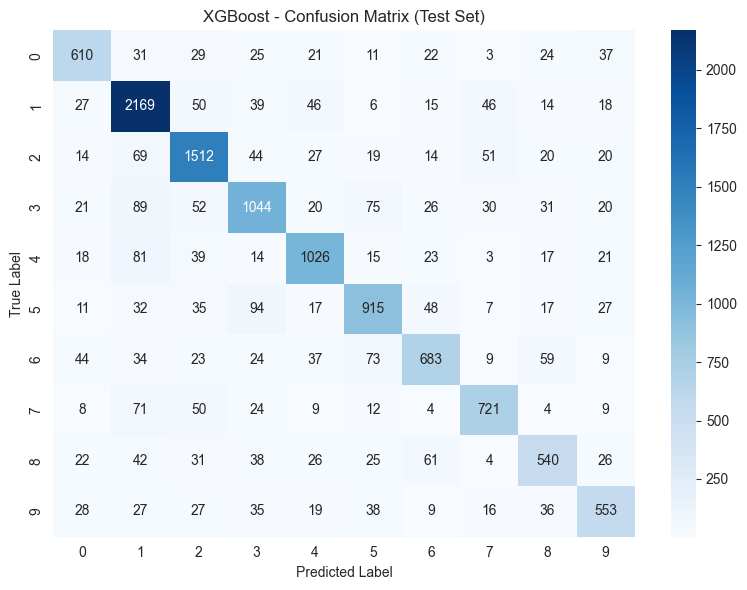

In [16]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.2 Visualize Confusion Matrix

In [17]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.76      0.75      0.75       813
           1       0.82      0.89      0.85      2430
           2       0.82      0.84      0.83      1790
           3       0.76      0.74      0.75      1408
           4       0.82      0.82      0.82      1257
           5       0.77      0.76      0.77      1203
           6       0.75      0.69      0.72       995
           7       0.81      0.79      0.80       912
           8       0.71      0.66      0.68       815
           9       0.75      0.70      0.72       788

    accuracy                           0.79     12411
   macro avg       0.78      0.76      0.77     12411
weighted avg       0.79      0.79      0.79     12411



### 8.1 Classification Report

In [18]:
# Salvar resultados finais usando função do módulo
model_final_results = save_final_results(
    model_name=MODEL_NAME,
    best_params=best_params,
    best_score=best_score,
    train_metrics=train_metrics,
    test_metrics=test_metrics,
    y_pred=y_test_pred,
    y_test=y_test_eval,
    X_train_scaled=X_train_eval,
    X_test_scaled=X_test_eval,
    results_folder=RESULTS_FOLDER
)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"F1-Score CV: {model_final_results['best_cv_score']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")
print(f"G-Mean Teste: {test_metrics['gmean']:.4f}")

print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"\nAvaliação do {MODEL_NAME} concluída com sucesso!")

✅ Resultados XGBoost salvos em: results\xgboost_results.json

--- RESUMO FINAL XGBoost ---
F1-Score CV: 0.4700
F1-Score Teste: 0.7702
Acurácia Teste: 0.7874
Precisão Teste: 0.7766
Recall Teste: 0.7647
G-Mean Teste: 0.7617
Resultados salvos em: results/

Avaliação do XGBoost concluída com sucesso!
